# **Problem Understanding & Initial EDA**

## Problem Statement

The aim of this project is to analyze the Ecommerce Customer Behavior Dataset and predict whether a customer will churn using machine learning.

The model uses customer demographics, purchase history, and browsing behavior to identify customers who are likely to leave the platform.

### Target Variable

#### Churn

* Binary variable (0 = No, 1 = Yes)
* Predicts whether a customer will churn.

### **Project Goal**

Build a classification model to predict customer churn and help improve customer retention.

# Dataset Description

* Customer behavior records from an e-commerce platform
* Numerical and categorical features
* Customer demographics and shopping behavior
* Purchase history and website activity
* Suitable for classification and customer churn prediction
* Useful for customer retention and business decision-making

## Examples of Features

* Age
* Gender
* Total_Purchases
* Average_Order_Value
* Session_Duration_Avg
* Pages_Per_Session
* Cart_Abandonment_Rate
* Wishlist_Items
* Membership_Level
* Churn (Target Variable)

## **Load Dataset**

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# df = pd.read_csv(r"C:\Users\user\Desktop\Machien learning Project\Data\ecommerce_customer_churn_dataset (1).csv")
# df.head()
df = pd.read_csv(r"C:\Users\user\Desktop\Machien learning Project\Data\ecommerce_customer_churn_dataset-selected-columns 123.csv")
df.head()

,Age,Gender,Country,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Churned
0,43.0,Male,France,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,0
1,36.0,Male,UK,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,0
2,45.0,Female,Canada,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,0
3,56.0,Female,USA,2.6,10.0,38.4,14.8,41.7,9.0,15.0,147.33,0
4,35.0,Male,India,3.1,29.0,51.4,NaN,19.1,9.0,32.5,141.30,0


## **Check Dataset Shape**

In [38]:
df.shape

(50000, 12)

## **Display Columns**

In [39]:
df.columns

Index(['Age', 'Gender', 'Country', 'Membership_Years', 'Login_Frequency',
       'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate',
       'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Churned'],
      dtype='object')

## **Dataset Structure**

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    47505 non-null  float64
 1   Gender                 50000 non-null  object 
 2   Country                50000 non-null  object 
 3   Membership_Years       50000 non-null  float64
 4   Login_Frequency        50000 non-null  float64
 5   Session_Duration_Avg   46601 non-null  float64
 6   Pages_Per_Session      47000 non-null  float64
 7   Cart_Abandonment_Rate  50000 non-null  float64
 8   Wishlist_Items         46000 non-null  float64
 9   Total_Purchases        50000 non-null  float64
 10  Average_Order_Value    50000 non-null  float64
 11  Churned                50000 non-null  int64  
dtypes: float64(9), int64(1), object(2)
memory usage: 4.6+ MB


## **Missing Values**

In [41]:
df.isnull().sum()

Age                      2495
Gender                      0
Country                     0
Membership_Years            0
Login_Frequency             0
Session_Duration_Avg     3399
Pages_Per_Session        3000
Cart_Abandonment_Rate       0
Wishlist_Items           4000
Total_Purchases             0
Average_Order_Value         0
Churned                     0
dtype: int64

## **Duplicate Rows**

In [42]:
df.duplicated().sum()

np.int64(0)

## **Summary Statistics**

In [43]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,1.000000


## **Numerical Features**

In [44]:
num_cols=df.select_dtypes(include=np.number).columns

num_cols

Index(['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg',
       'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items',
       'Total_Purchases', 'Average_Order_Value', 'Churned'],
      dtype='object')

## **Categorical Features**

In [45]:
cat_cols=df.select_dtypes(include="object").columns

cat_cols

Index(['Gender', 'Country'], dtype='object')

## **Target Variable**

In [46]:
df["Churned"].value_counts()

Churned
0    35550
1    14450
Name: count, dtype: int64

## **Target Variable Percentage**

In [47]:
df["Churned"].value_counts(normalize=True)*100

Churned
0    71.1
1    28.9
Name: proportion, dtype: float64

# **Exploratory Data Analysis**

EDA is performed to understand the characteristics of the dataset and identify patterns that may influence customer churn.

The objectives of EDA are:

* Understand customer behavior
* Identify important variables
* Detect missing values
* Detect outliers
* Examine relationships between variables
* Explore factors influencing customer churn

## **Customer Churn Distribution**

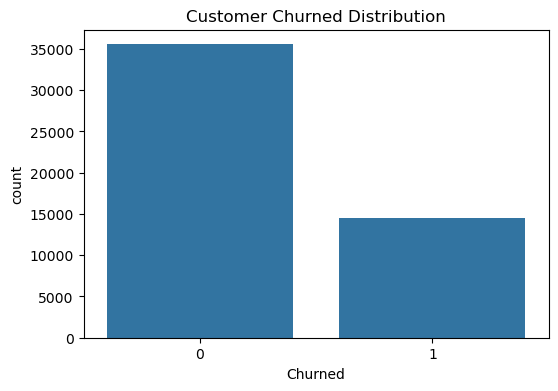

In [48]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churned")

plt.title("Customer Churned Distribution")
plt.show()

## **Gender vs Customer Churn**

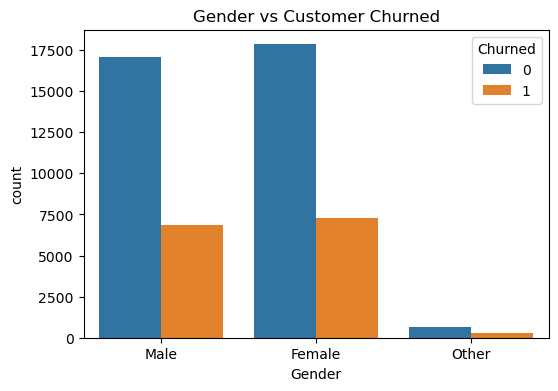

In [49]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="Gender",
              hue="Churned")

plt.title("Gender vs Customer Churned")
plt.show()

## **Membership Level vs Customer Churn**

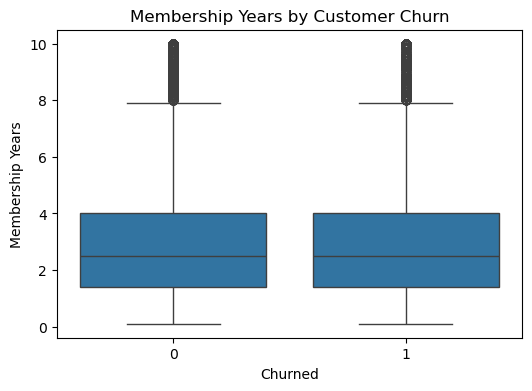

In [62]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Churned",
    y="Membership_Years"
)

plt.title("Membership Years by Customer Churn")
plt.xlabel("Churned")
plt.ylabel("Membership Years")
plt.show()

## **Session Duration Distribution**

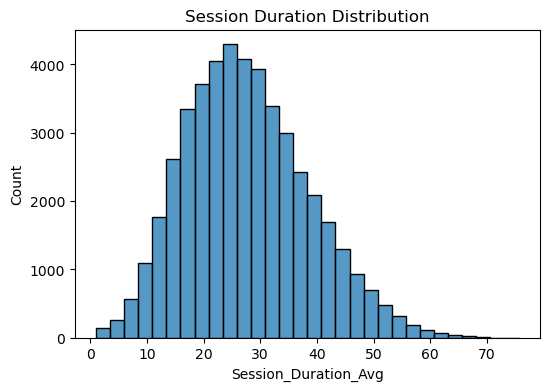

In [52]:
plt.figure(figsize=(6,4))

sns.histplot(df["Session_Duration_Avg"], bins=30)

plt.title("Session Duration Distribution")
plt.show()

## **Feature Correlation Heatmap**

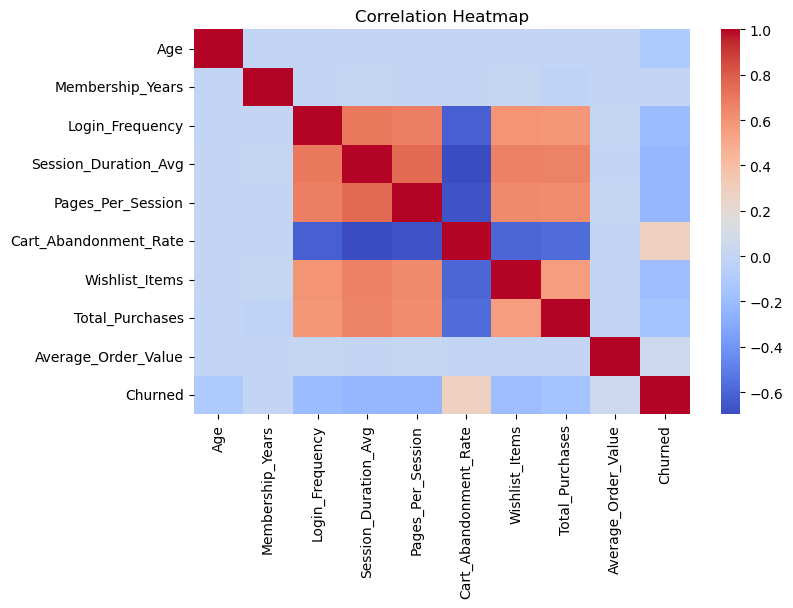

In [63]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True),
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

## **Average Order Value vs Total Purchases**

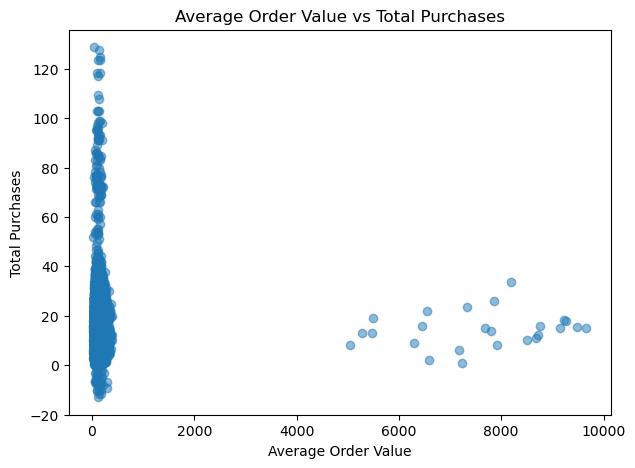

In [65]:
plt.figure(figsize=(7,5))

plt.scatter(df["Average_Order_Value"],
            df["Total_Purchases"],
            alpha=0.5)

plt.title("Average Order Value vs Total Purchases")
plt.xlabel("Average Order Value")
plt.ylabel("Total Purchases")

plt.show()

## Key Patterns Discovered

#### 1. Customer Churn

A noticeable number of customers have churned, indicating the importance of identifying churn behavior.

#### 2. Membership Duration

Customers with shorter membership periods are more likely to churn than long-term members.

#### 3. Purchase Behavior

Customers with fewer total purchases tend to have a higher churn rate.

#### 4. Session Activity

Customers with shorter session durations and fewer pages per session are more likely to churn.

#### 5. Cart Abandonment

Higher cart abandonment rates are associated with increased customer churn.

#### 6. Customer Engagement

Customers with more wishlist items and frequent purchases generally show lower churn rates.

#### 7. Missing Values

Missing values were identified and handled appropriately before model development.

#### 8. Numerical Relationships

Several numerical features show relationships with customer churn and can be useful predictors for machine learning.